In [31]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

from boed.priors.kernels import Gaussian, Matern32
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel,ColoredNoise

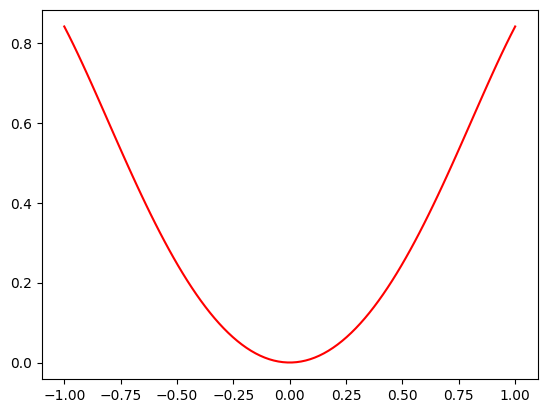

In [32]:
N = 100
x = np.linspace(-1,1,N)
theta = np.sin(x**2) # param of interest
plt.plot(x, theta, "r")

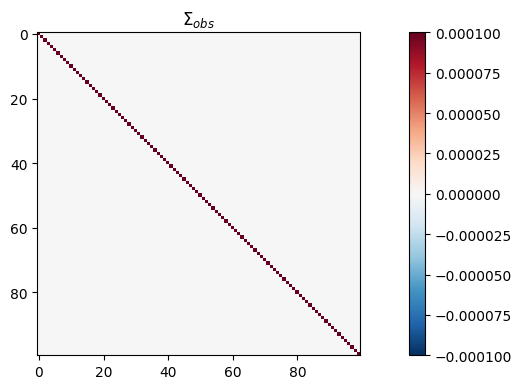

In [33]:
# Observation noise
sigma = 0.01
noise = NoiseModel(sigma_noise=sigma)
Sigma_obs = noise.get_covariance(N)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

vmax = np.abs(Sigma_obs).max()
im = ax.imshow(Sigma_obs, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_title(r"$\Sigma_{obs}$")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

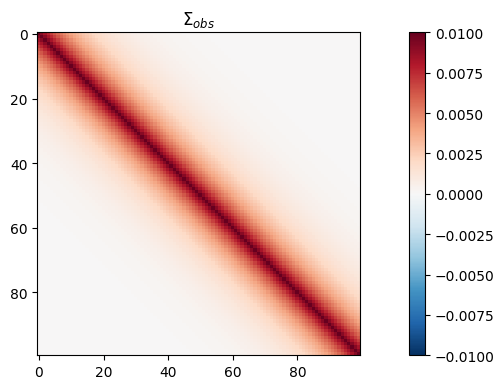

In [34]:
# Observation noise
sigma = 0.1
noise = ColoredNoise(sigma_noise=sigma,correlation_length=10.6)
Sigma_obs_colored = noise.get_covariance(N)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

vmax = np.abs(Sigma_obs_colored).max()
im = ax.imshow(Sigma_obs_colored, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_title(r"$\Sigma_{obs}$")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

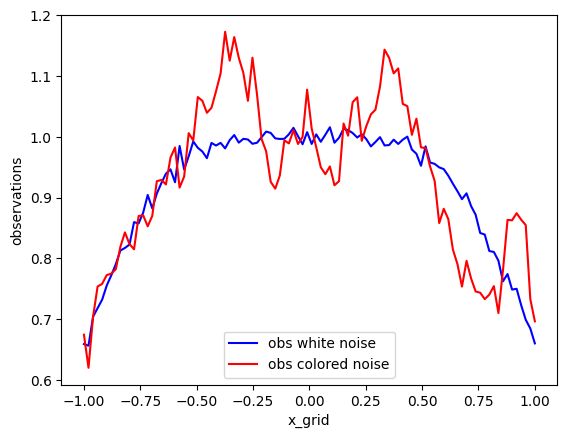

In [38]:

y = np.cos(theta) + np.random.multivariate_normal(mean=np.zeros(N),cov=Sigma_obs)
yc = np.cos(theta) + np.random.multivariate_normal(mean=np.zeros(N),cov=Sigma_obs_colored)
plt.plot(x, y, "b", label="obs white noise")
plt.plot(x, yc,"r", label="obs colored noise")
plt.xlabel("x_grid")
plt.ylabel("observations")
plt.legend()

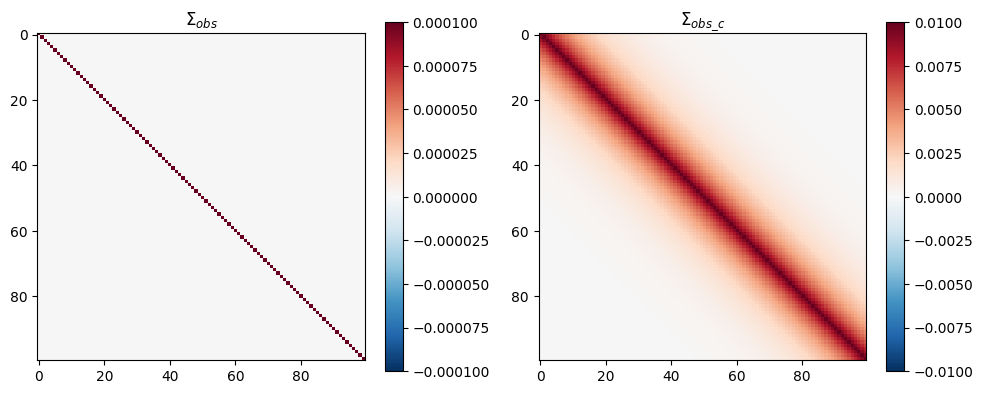

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [Sigma_obs, Sigma_obs_colored], [r"$\Sigma_{obs}$", r"$\Sigma_{obs\_c}$"]):
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [41]:
# Prior 
from boed.priors.kernels import Gaussian, Matern32, Matern12,Matern52
from boed.priors.gp_priors import GaussianProcessPrior

In [70]:
length_scale , sigma_prior = 0.2, 0.5
mat12 = Matern12(length_scale=length_scale, sigma=sigma_prior)
prior_mat12  = GaussianProcessPrior(mat12, nx=N)

mat32 = Matern32(length_scale=length_scale, sigma=sigma_prior)
prior_mat32  = GaussianProcessPrior(mat32, nx=N)

mat52 = Matern52(length_scale=length_scale, sigma=sigma_prior)
prior_mat52  = GaussianProcessPrior(mat52, nx=N)

gauss = Gaussian(length_scale=length_scale, sigma=sigma_prior)
prior_gauss  = GaussianProcessPrior(gauss, nx=N)

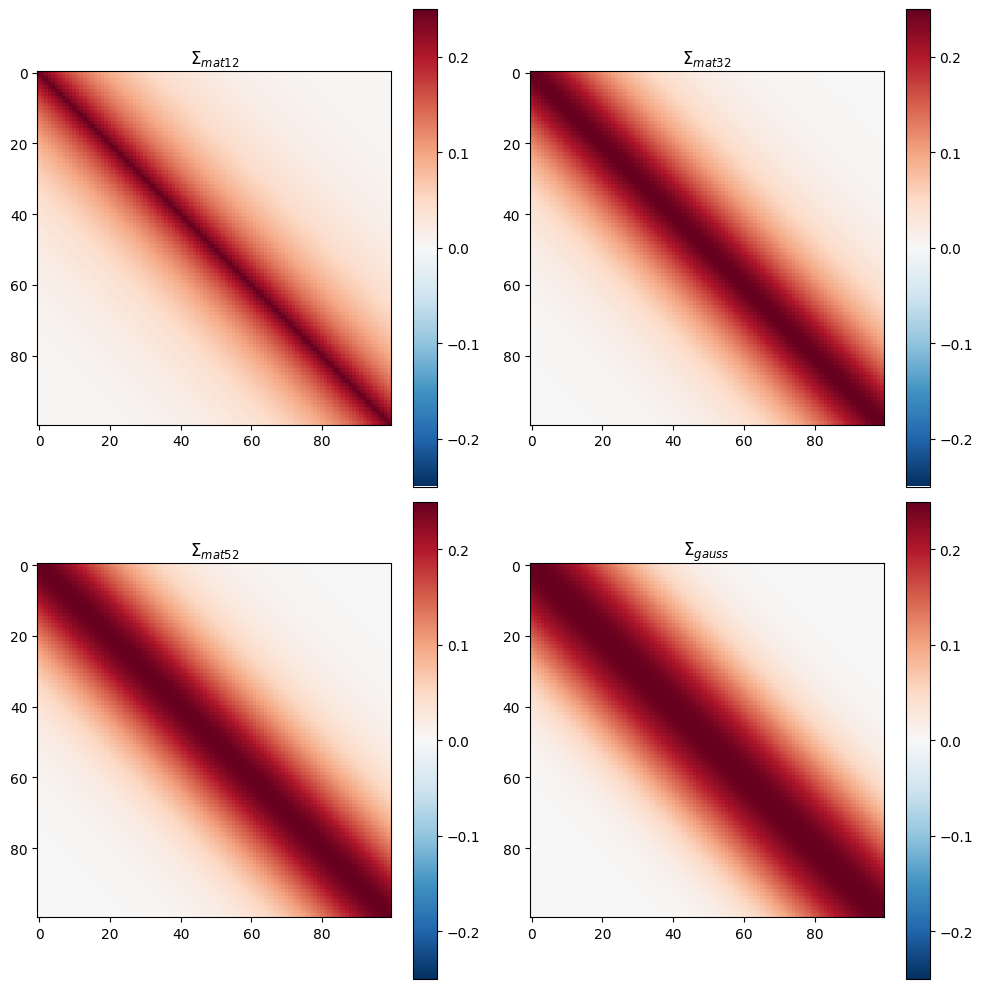

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
kernels = [prior_mat12.Sigma, prior_mat32.Sigma, prior_mat52.Sigma, prior_gauss.Sigma]
for ax, mat, title in zip(axes.ravel(), kernels, [r"$\Sigma_{mat12}$", r"$\Sigma_{mat32}$", r"$\Sigma_{mat52}$", r"$\Sigma_{gauss}$"]):
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

(100,)


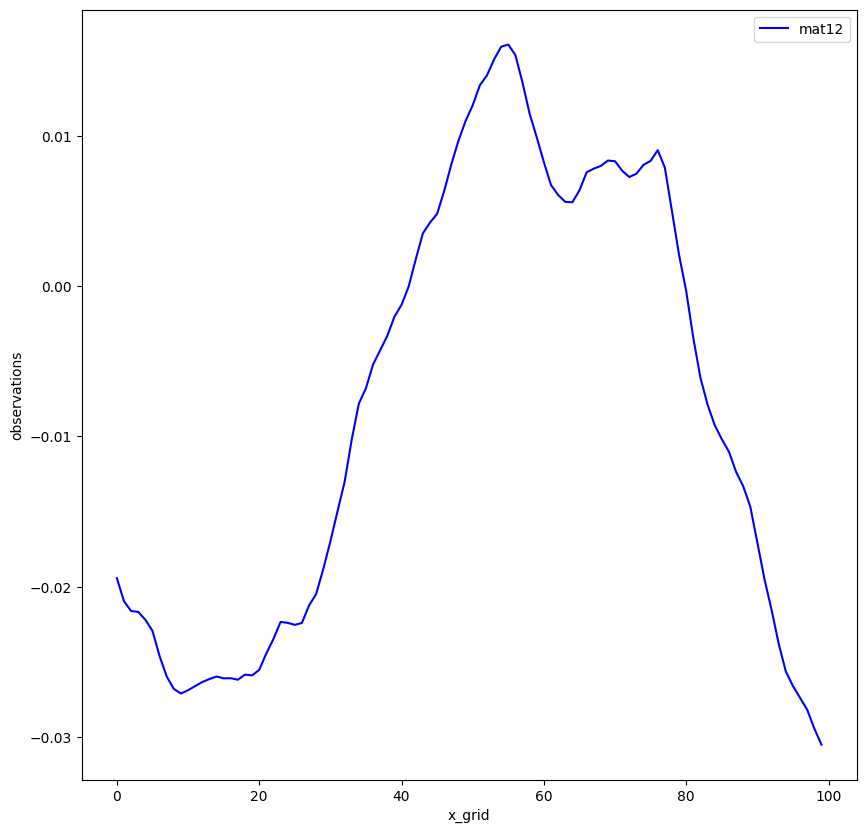

In [75]:
mat_dist12 =np.random.multivariate_normal(mean=prior_mat32.mu, cov=prior_mat32.Sigma, size=1000)
print(np.mean(mat_dist12,axis=0).shape)

fig, axes = plt.subplots(1, 1, figsize=(10, 10))

plt.plot(np.mean(mat_dist12,axis=0), "b", label="mat12")
plt.xlabel("x_grid")
plt.ylabel("observations")
plt.legend()

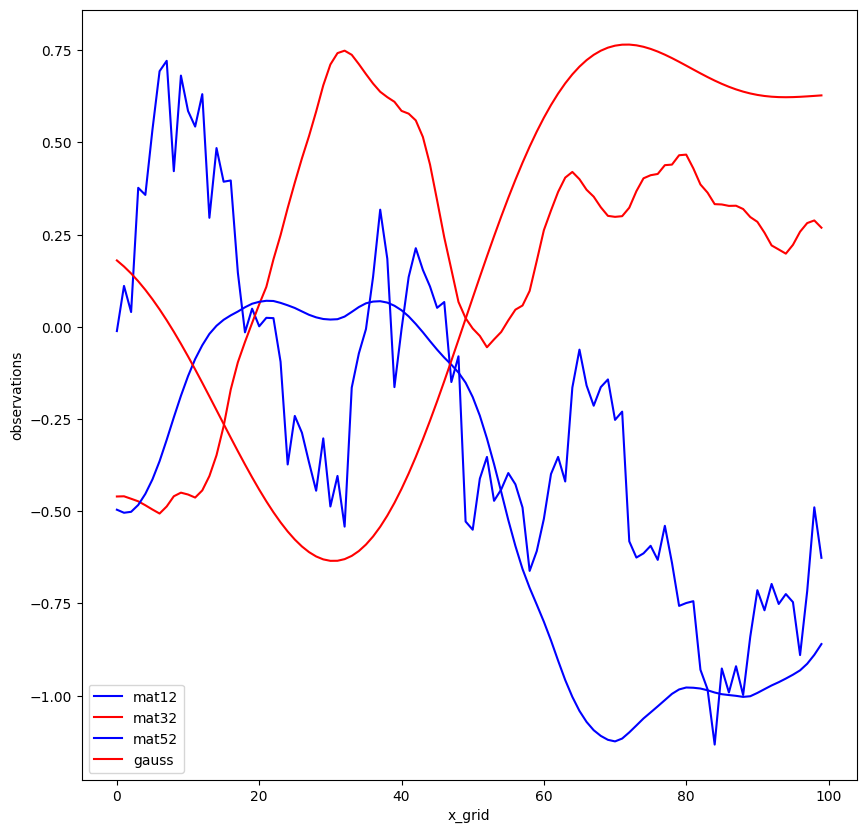

In [73]:
mat_dist12 =np.random.multivariate_normal(mean=prior_mat12.mu, cov=prior_mat12.Sigma)
mat_dist32 =np.random.multivariate_normal(mean=prior_mat32.mu, cov=prior_mat32.Sigma)
mat_dist52 =np.random.multivariate_normal(mean=prior_mat52.mu, cov=prior_mat52.Sigma)
mat_distgauss =np.random.multivariate_normal(mean=prior_gauss.mu, cov=prior_gauss.Sigma)
y = [mat_dist12, mat_dist32, mat_dist52, mat_distgauss]
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

plt.plot(y[0], "b", label="mat12")
plt.plot(y[1],"r", label="mat32")
plt.plot(y[2], "b", label="mat52")
plt.plot(y[3],"r", label="gauss")
plt.xlabel("x_grid")
plt.ylabel("observations")
plt.legend()